In [1]:
from Environment import evaluate_performance
from Environment import plot_HVAC_results
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from professor_model import evaluate_hindsight_model
from SystemCharacteristics import get_fixed_data

FIXED_DATA = get_fixed_data()

# Evaluating and comparing policies and hindsight solution in one go using predefined data

Evaluating policy: Lookahead_policy_20
Average daily cost over 100 days: 185.06 €


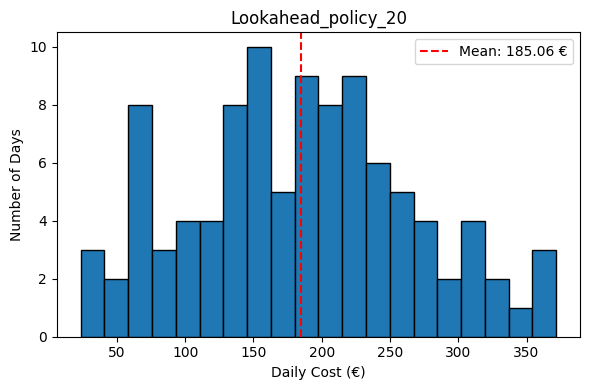

C:\Users\fabia\AppData\Local\Temp\ipykernel_14400\4177067681.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(sorted_policies, rotation=15, ha='right')


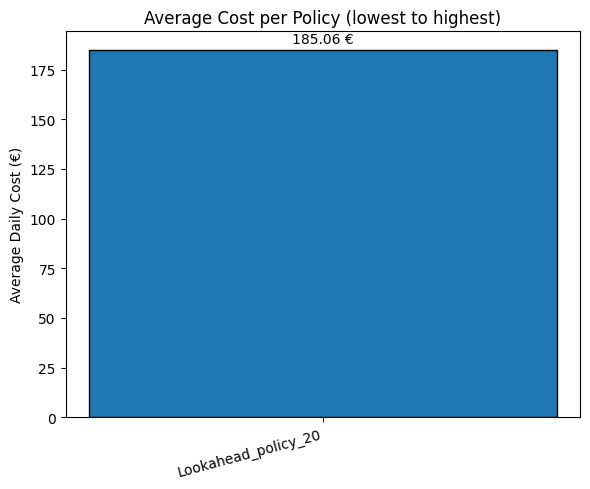

In [ ]:
policies = [
    "Hindsight_policy_20",
    "Dummy_policy_20",
    "Lookahead_policy_20",
    # "SPTwoStage_policy_20",
    "SP_policy_20",
    # "ADP_policy_20",
    # "Hybrid_policy_20"
    ]

master_results = {}

# Data files
DIR = Path(os.getcwd())
price_file = DIR / "PriceData.csv"
occupancy1_file = DIR / "OccupancyRoom1.csv"
occupancy2_file = DIR / "OccupancyRoom2.csv"
num_days = 100


fig, axes = plt.subplots(1, len(policies), figsize=(6 * len(policies), 4), squeeze=False)

for i, policy in enumerate(policies):
    
    print(f"Evaluating policy: {policy}")
    if policy == "Hindsight_policy_20":
        results = evaluate_hindsight_model(num_days, file_price_data=price_file, file_occupancy1=occupancy1_file, file_occupancy2=occupancy2_file)
    else:
        results = evaluate_performance(policy, num_days, file_price_data=price_file, file_occupancy1=occupancy1_file, file_occupancy2=occupancy2_file)
    
    daily_costs = [res['cost_total'] for res in results]
    avg_cost = np.mean(daily_costs)
    master_results[policy] = results
    print(f"Average daily cost over {len(results)} days: {avg_cost:.2f} €")

    ax = axes[0][i]
    ax.hist(daily_costs, bins=20, edgecolor='black')
    ax.axvline(avg_cost, color='red', linestyle='--', label=f'Mean: {avg_cost:.2f} €')
    ax.set_title(policy)
    ax.set_xlabel("Daily Cost (€)")
    ax.set_ylabel("Number of Days")
    ax.legend()

plt.tight_layout()
plt.show()

# Bar chart: average cost per policy, sorted lowest to highest
avg_costs = {p: np.mean([r['cost_total'] for r in master_results[p]]) for p in policies}
sorted_policies = sorted(avg_costs, key=avg_costs.get)
sorted_costs = [avg_costs[p] for p in sorted_policies]

fig2, ax2 = plt.subplots(figsize=(max(6, len(policies) * 1.5), 5))
bars = ax2.bar(sorted_policies, sorted_costs, edgecolor='black')
ax2.bar_label(bars, fmt='%.2f €', padding=3)
ax2.set_ylabel("Average Daily Cost (€)")
ax2.set_title("Average Cost per Policy (lowest to highest)")
ax2.set_xticklabels(sorted_policies, rotation=15, ha='right')
plt.tight_layout()
plt.show()

Random tests